In [1]:
import numpy as np
from scipy.stats import poisson

def average_upper_limit_poisson(nb, confidence_level=0.9, Ntoy=10_000):
    """
    Stima 'media' del limite superiore a un certo livello di confidenza
    per un numero di eventi osservati con background nb (senza segnale),
    usando una procedura semplificata:
      - Genera Ntoy pseudo-esperimenti con n_obs ~ Poisson(nb)
      - Per ognuno calcola un limite superiore N_limit_i a CL=confidence_level
      - Ritorna la media <N_limit>
    
    Parametri:
      nb : float
        Valore atteso di background
      confidence_level : float
        Livello di confidenza (default 0.9 per 90% CL)
      Ntoy : int
        Numero di pseudo-esperimenti
    Ritorna:
      avg_ul : float
        Valore medio di N_limit (sul totale di Ntoy esperimenti)
    """
    # Genera i conteggi osservati con background nb
    n_obs_array = poisson.rvs(nb, size=Ntoy)

    ul_values = []
    for n_obs in n_obs_array:
        # Limite superiore "naif" a CL usando quantile di Poisson
        # (Si aggiunge +1 per evitare ppf(..., 0))
        ul = poisson.ppf(confidence_level, n_obs + 1)
        
        # Qui stiamo calcolando un limite sul TOTALE eventi (signal+bkg).
        # Se vuoi il limite SOLO sul segnale, fai: max(0, ul - nb).
        # Ma la definizione di "average upper limit" può variare.
        ul_values.append(ul)
    
    avg_ul = np.mean(ul_values)
    return avg_ul

# Esempio di utilizzo
if __name__ == "__main__":
    # Background atteso
    nb = 3.0

    # Numero medio di eventi segnale previsti dal tuo modello
    n_s_mean = 10.0
    
    # Flusso del tuo modello
    Phi_model = 1e-15  # Adatta alle tue unità

    # Calcoliamo l'average upper limit in assenza di segnale
    N_limit_avg = average_upper_limit_poisson(nb, confidence_level=0.9, Ntoy=100000)
    
    # MRF = <N_limit> / n_s
    MRF = N_limit_avg / n_s_mean
    
    # Sensibilità in flusso: Φ₉₀ = Φ_model * MRF
    Phi_90 = Phi_model * MRF
    
    print(f"Background atteso (nb) = {nb}")
    print(f"Segnale atteso (n_s_mean) = {n_s_mean}")
    print(f"Average upper limit <N_limit> (90% CL) = {N_limit_avg:.2f}")
    print(f"MRF = {MRF:.3f}")
    print(f"Phi_90 = {Phi_90:.3e}")


Background atteso (nb) = 3.0
Segnale atteso (n_s_mean) = 10.0
Average upper limit <N_limit> (90% CL) = 6.56
MRF = 0.656
Phi_90 = 6.560e-16


In [39]:
import numpy as np
import math
from scipy.stats import poisson

# Cache per evitare di ricalcolare il limite per lo stesso n_obs
fc_cache = {}

def is_in_acceptance(s, nb, n_obs, CL):
    """
    Data un'ipotesi di segnale s e background nb,
    calcola la regione di accettazione Feldman-Cousins (usando l'ordinamento per R)
    e restituisce True se n_obs è incluso nella regione (al livello CL).
    """
    # Scegliamo un intervallo discreto di n: da 0 a n_max
    n_max = int(max(n_obs + 20, s + nb + 10))
    ns = np.arange(0, n_max + 1)
    
    # Calcola P(n | s+nb)
    p_n = poisson.pmf(ns, s + nb)
    
    # Calcola s_best per ogni n: s_best = max(0, n - nb)
    s_best = np.maximum(0, ns - nb)
    p_best = poisson.pmf(ns, s_best + nb)
    
    # Calcola il rapporto di verosimiglianza R(n; s)
    with np.errstate(divide='ignore', invalid='ignore'):
        R = np.where(p_best > 0, p_n / p_best, 0)
    
    # Ordina gli indici in ordine decrescente di R
    order = np.argsort(-R)
    
    cumulative = 0.0
    accepted = []
    for idx in order:
        cumulative += p_n[idx]
        accepted.append(ns[idx])
        if cumulative >= CL:
            break

    return n_obs in accepted

def fc_upper(n_obs, nb, CL=0.9, s_max=50, tol=1e-3):
    """
    Trova, per un dato n_obs e background nb, il limite superiore sul segnale s
    usando il metodo Feldman-Cousins a livello CL.
    Si utilizza una ricerca per bisezione sull'intervallo s ∈ [0, s_max].
    """
    # Se n_obs è 0, il limite superiore Feldman-Cousins coincide con un certo valore;
    # tuttavia il procedimento bisezione funziona in ogni caso.
    s_low = 0.0
    s_high = s_max
    # Eseguiamo la ricerca finché l'intervallo ha lunghezza > tol
    while s_high - s_low > tol:
        s_mid = 0.5 * (s_low + s_high)
        # Se n_obs è ancora nella regione di accettazione per s_mid, possiamo aumentare s
        if is_in_acceptance(s_mid, nb, n_obs, CL):
            s_low = s_mid
        else:
            s_high = s_mid
    return s_low

def fc_upper_cached(n_obs, nb, CL=0.9):
    """
    Funzione wrapper che utilizza un dizionario cache per fc_upper.
    """
    if n_obs in fc_cache:
        return fc_cache[n_obs]
    else:
        ul = fc_upper(n_obs, nb, CL)
        fc_cache[n_obs] = ul
        return ul

def average_upper_limit_feldman_cousins(nb, confidence_level=0.9, Ntoy=10_000):
    """
    Stima 'media' del limite superiore Feldman-Cousins a un certo livello di confidenza
    per un numero di eventi osservati con background nb (senza segnale), usando una procedura:
      - Genera Ntoy pseudo-esperimenti con n_obs ~ Poisson(nb)
      - Per ognuno calcola il limite superiore N_limit_i tramite il metodo Feldman-Cousins
      - Ritorna la media <N_limit>
    
    Parametri:
      nb : float
        Valore atteso di background.
      confidence_level : float
        Livello di confidenza (default 0.9 per 90% CL).
      Ntoy : int
        Numero di pseudo-esperimenti.
        
    Ritorna:
      avg_ul : float
        Valore medio di N_limit (sul totale di Ntoy esperimenti).
    """
    # Genera i conteggi osservati (usiamo la distribuzione Poisson per simulare n_obs)
    n_obs_array = poisson.rvs(nb, size=Ntoy)
    
    ul_values = []
    for n_obs in n_obs_array:
        ul = fc_upper_cached(n_obs, nb, confidence_level)
        ul_values.append(ul)
    
    avg_ul = np.mean(ul_values)
    return avg_ul

# Esempio di utilizzo
if __name__ == "__main__":
    # Background atteso
    #nb = 0.173 -10
    #nb = 0.193  -20
    #nb = 0.214  -30
    nb = 0.242  #-40
    #nb = 0.315
    # Numero medio di eventi segnale previsti dal tuo modello
    n_s_mean = 3.718e3
    
    # Flusso del tuo modello (adatta le unità)
    #Phi_model = 1e-15

    # Calcola l'average upper limit usando Feldman-Cousins in assenza di segnale
    N_limit_avg = average_upper_limit_feldman_cousins(nb, confidence_level=0.9, Ntoy=10000)
    
    # MRF = <N_limit> / n_s_mean
    MRF = N_limit_avg / n_s_mean
    
    # Sensibilità in flusso: Phi_90 = Phi_model * MRF
    #Phi_90 = Phi_model * MRF
    
    print(f"Background atteso (nb) = {nb}")
    print(f"Segnale atteso (n_s_mean) = {n_s_mean}")
    print(f"Average upper limit <N_limit> (90% CL, Feldman-Cousins) = {N_limit_avg:.2f}")
    print(f"MRF = {MRF:.3f}")
    #print(f"Phi_90 = {Phi_90:.3e}")


Background atteso (nb) = 0.242
Segnale atteso (n_s_mean) = 3718.0
Average upper limit <N_limit> (90% CL, Feldman-Cousins) = 2.64
MRF = 0.001


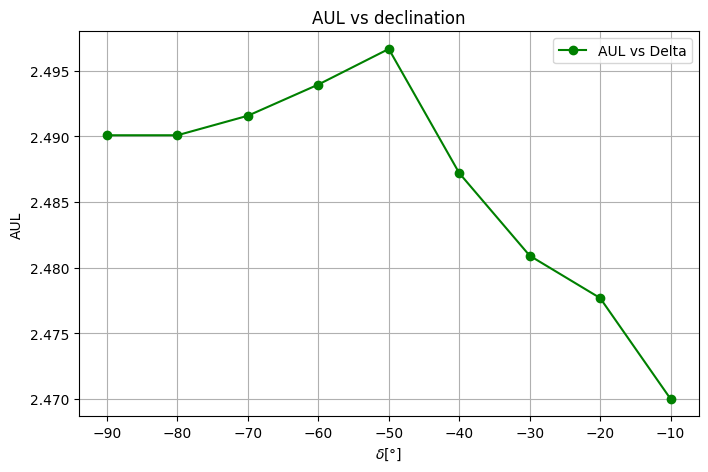

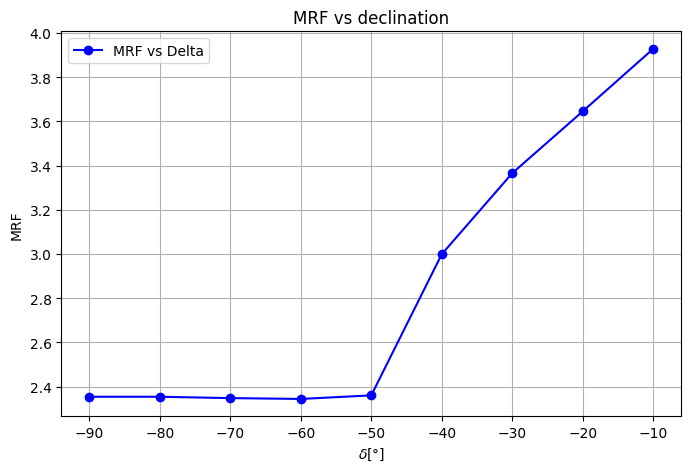

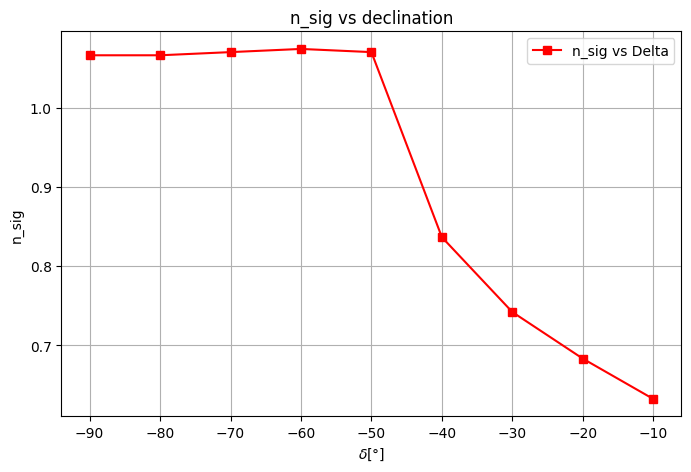

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Liste di valori per n_bk, n_sig e MRF
#n_bk_list = [0.1737795, 0.1934125, 0.2139706, 0.2422314, 0.3152826, 0.2959751, 0.278211, 0.2619555, 0.2619555]
#n_sig_list = [14370.0, 15520.0, 16840.0, 18970.0, 24250.0, 24400.0, 24400.0, 24310.0, 24310.0]
#n_sig_list = [1.437e-2, 1.552e-2, 1.684e-2, 1.897e-2, 2.425e-2, 2.440e-2, 2.440e-2, 2.431e-2, 2.431e-2]
#MRF_list = [0.0001804737273176269, 0.00016816258464959528, 0.00015605397305432645, 0.00013974782263055234, 0.0001119033291272555, 0.00011043506813286942,
#0.00010987981613054225, 0.00010972045282977468, 0.00010972045282977468] 10 Kpc
#MRF_list = [1.804737273176269, 1.6816258464959528, 1.5605397305432645, 1.3974782263055234, 1.119033291272555, 1.1043506813286942, 1.0987981613054225, 1.0972045282977468, 1.0972045282977468]
#n_sig_list = [1.437, 1.552, 1.684, 1.897, 2.425, 2.440, 2.440, 2.431, 2.431] 
# Dati per Anumu
n_sig_anumu = [0.6322, 0.6831, 0.7419, 0.8364, 1.07, 1.074, 1.07, 1.066, 1.066]
MRF_anumu = [3.92757362601086, 3.644897658306548, 3.3651857634846176, 2.998670952549012, 
             2.3602119426061714, 2.344044798820527, 2.3478089739641577, 2.353889381786633, 2.353889381786633]

# Dati per Numu
n_sig_numu = [0.8053, 0.8684, 0.942, 1.061, 1.355, 1.366, 1.37, 1.365, 1.365]
MRF_numu = [3.163749549752713, 2.946276614725238, 2.73820965099567, 2.4422474169967283, 
            1.9462403738061123, 1.9210282792466063, 1.908465212672826, 1.9065451744452753, 1.9065451744452753]


MRF_list = [1.718861071354388, 1.5964448412023353, 1.4732240373920906, 1.3111208048467595, 1.0295451536641387, 1.0221052451502877, 1.0211320632838197, 1.0243014532650758, 1.0243014532650758]
AUL_list = [2.4700033595362556, 2.4776823935460244, 2.4809092789682805, 2.4871961667943028, 2.496646997635536, 2.4939367981667018, 2.49156223441252, 2.4900768328873992, 2.4900768328873992]

# Definizione della declinazione delta da -10 a -90 con lo stesso numero di punti
num_points = len(MRF_list)
delta_list = np.linspace(-10, -90, num_points)

# Plot di AUL vs declinazione
plt.figure(figsize=(8, 5))
plt.plot(delta_list, AUL_list, marker='o', linestyle='-', color='g', label='AUL vs Delta')
plt.xlabel(r'$\delta [°]$')
plt.ylabel('AUL')

plt.title('AUL vs declination')
plt.legend()
plt.grid()
plt.show()


# Plot di MRF vs declinazione
plt.figure(figsize=(8, 5))
plt.plot(delta_list, MRF_anumu, marker='o', linestyle='-', color='b', label='MRF vs Delta')
plt.xlabel(r'$\delta [°]$')
plt.ylabel('MRF')

plt.title('MRF vs declination')
plt.legend()
plt.grid()
plt.show()

# Plot di n_sig vs declinazione
plt.figure(figsize=(8, 5))
plt.plot(delta_list,n_sig_anumu, marker='s', linestyle='-', color='r', label='n_sig vs Delta')
plt.xlabel(r'$\delta [°]$')
plt.ylabel('n_sig')

plt.title('n_sig vs declination')
plt.legend()
plt.grid()
plt.show()


CALCRATE

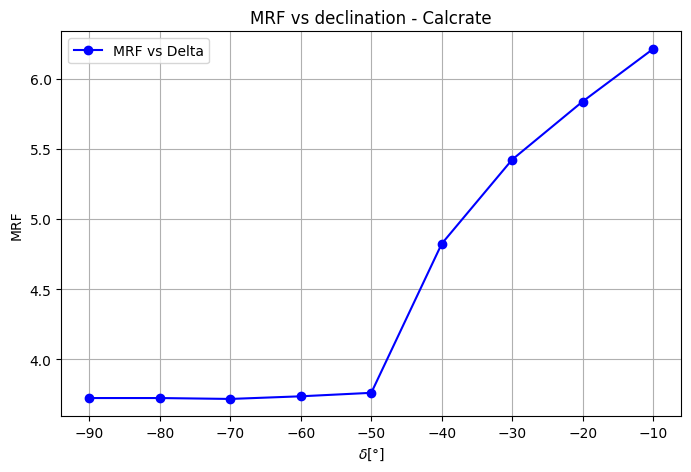

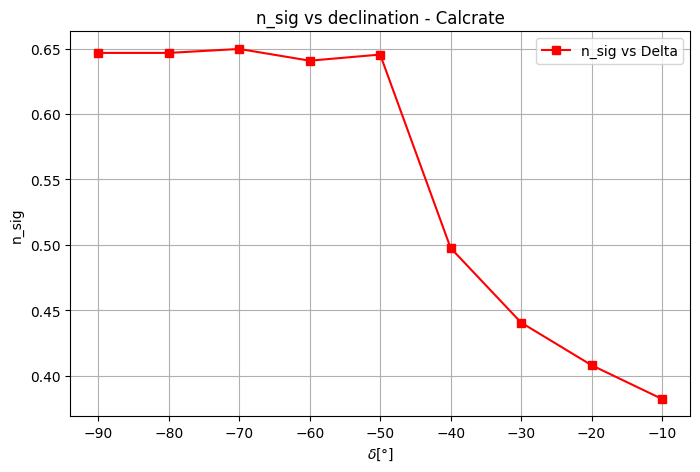

In [12]:


total_sig_list_c = [1.39657, 1.49356, 1.61448, 1.82394, 2.36489, 2.36891, 2.36981, 2.35872, 2.35872]

MRF_list_c = [1.72018, 1.61583, 1.50191, 1.33802, 1.04885, 1.04264, 1.03815, 1.03926, 1.03926]
total_sig_numu_c = [0.382147, 0.407962, 0.440563, 0.497599, 0.645541, 0.640857, 0.649841, 0.646808, 0.646808]
MRF_numu_c = [6.21081, 5.83649, 5.42283, 4.82351, 3.76183, 3.73708, 3.71826, 3.72466, 3.72466]
num_points = len(MRF_numu_c)
delta_list = np.linspace(-10, -90, num_points)
# Plot di MRF vs declinazione
plt.figure(figsize=(8, 5))
plt.plot(delta_list, MRF_numu_c, marker='o', linestyle='-', color='b', label='MRF vs Delta')
plt.xlabel(r'$\delta [°]$')
plt.ylabel('MRF')

plt.title('MRF vs declination - Calcrate')
plt.legend()
plt.grid()
plt.show()

# Plot di n_sig vs declinazione
plt.figure(figsize=(8, 5))
plt.plot(delta_list,total_sig_numu_c, marker='s', linestyle='-', color='r', label='n_sig vs Delta')
plt.xlabel(r'$\delta [°]$')
plt.ylabel('n_sig')

plt.title('n_sig vs declination - Calcrate')
plt.legend()
plt.grid()
plt.show()

In [29]:
def save_data(filename, data1, data2, header1="Column 1", header2="Column 2"):
    """
    Salva due array di dati in un file di testo con due colonne.

    Parameters:
    filename (str): Nome del file di output.
    data1 (numpy array): Primo array di dati.
    data2 (numpy array): Secondo array di dati.
    header1 (str): Intestazione della prima colonna.
    header2 (str): Intestazione della seconda colonna.

    Output:
    Un file di testo con due colonne: data1 e data2.
    """
    data_to_save = np.column_stack((data1, data2))  # Combina i dati in due colonne
    header = f"{header1}   {header2}"  # Crea l'intestazione dinamicamente
    np.savetxt(filename, data_to_save, fmt="%.6e", header=header, comments='')






Test SENSITIVITY

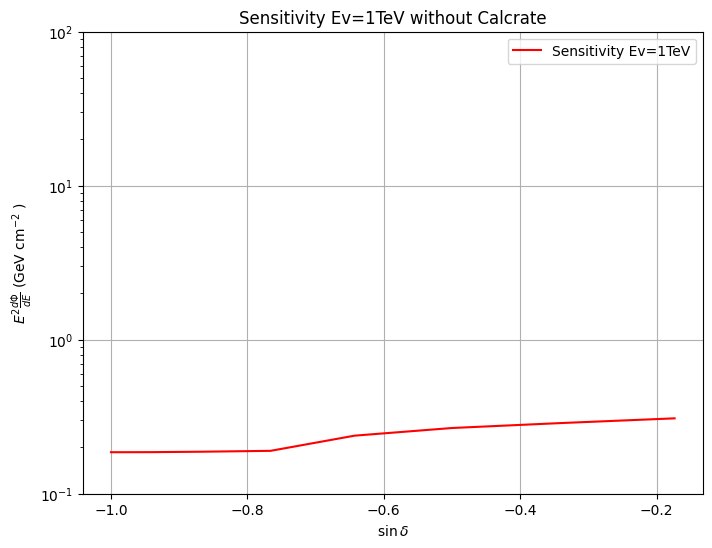

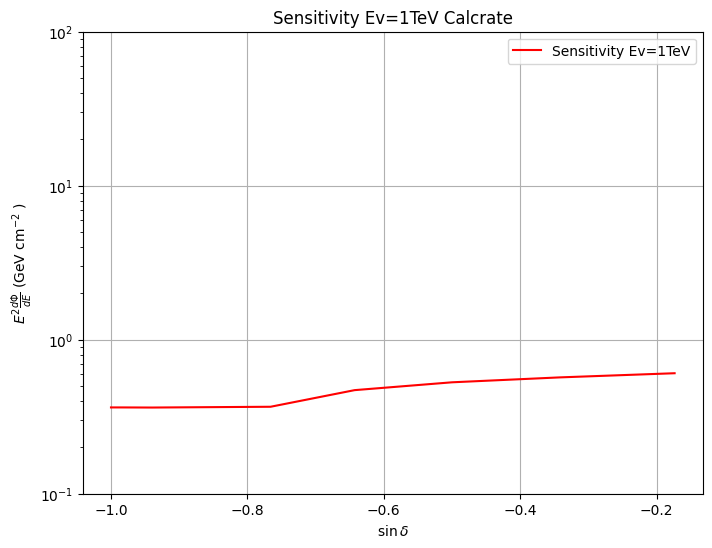

[array([0.3086552]), array([0.28743856]), array([0.26713956]), array([0.2382655]), array([0.18987508]), array([0.18741539]), array([0.18618974]), array([0.18600242]), array([0.18600242])]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dati di input
#num_points = len(MRF_list)
#delta_list = np.linspace(-90, -10, num_points)
  # Converti in sin(δ) in radianti


d = 1*3.086e24
d_c = 1*3.086e22
# Caricamento dati
data = np.loadtxt("SN_IIn/SNIIn_20_block_25.dat", skiprows=1)
#data = np.loadtxt("flux_IIn.dat", skiprows=1)
#dN_dEv = data[15, 1]/1e9
#flux = dN_dEv/(4*np.pi*d**2)

#sensitivity = [flux * mrf for mrf in MRF_list]
if data[-1, -1] == 1:
    Ev_all = data[:, 0]
    Ev = Ev_all[Ev_all == 1.07461e12]  # Seleziona valori di Ev maggiori di 3e8
    Ev_c = Ev_all[Ev_all > 0.3e8]/1e9
    #Selezione del valore specifico di Ev
    S_IIn_start = 1e5 * pow(10., 0.1 * (25 - 1)) 
    S_IIn_stop = 1e5 * pow(10., 0.1 * (26 - 1))
    delta = S_IIn_stop - S_IIn_start
    dN_dEv = data[:, 7]
    dN_dEv_c = data[:, 7][Ev_all>0.3e8]
    dN_dEv = dN_dEv * delta
    dN_dEv = dN_dEv[Ev_all == 1.07461e12]
    
    flux = Ev**2*dN_dEv/(6*1e9*4*np.pi*d**2)
    flux_c = dN_dEv_c*1e9/(6*4*np.pi*d_c**2)
    
    # Esempio di utilizzo per Ev_c e dN_dEv_c
    save_data("flux_c1.txt", Ev_c, flux_c, header1="Ev_c [GeV]", header2="dN_dEv_c [s^-1 GeV^-1]")
# Calcola la sensibilità per ogni δ
    sensitivity = [flux * mrf for mrf in MRF_numu]
    sensitivity_c = [flux * mrf for mrf in MRF_numu_c]


sin_delta = np.sin(np.radians(delta_list))
# Plot della sensibilità in funzione di sin(δ)
plt.figure(figsize=(8, 6))
plt.plot(sin_delta, sensitivity, color='red', label="Sensitivity Ev=1TeV")

# Formattazione del grafico
plt.xlabel(r"$\sin \delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV cm$^{-2}$ )")
plt.yscale("log")  # Scala logaritmica
plt.ylim(1e-1,1e2)
#plt.xscale("linear")  # x non serve in log
plt.grid(True)
plt.title('Sensitivity Ev=1TeV without Calcrate')
plt.legend()  # Aggiunge la legenda
plt.show()

# Plot della sensibilità in funzione di sin(δ)
plt.figure(figsize=(8, 6))
plt.plot(sin_delta, sensitivity_c, color='red', label="Sensitivity Ev=1TeV")

# Formattazione del grafico
plt.xlabel(r"$\sin \delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV cm$^{-2}$ )")
plt.yscale("log")  # Scala logaritmica
plt.ylim(1e-1,1e2)
#plt.xscale("linear")  # x non serve in log
plt.grid(True)
plt.title('Sensitivity Ev=1TeV Calcrate')
plt.legend()  # Aggiunge la legenda
plt.show()
print(sensitivity)



Anumu

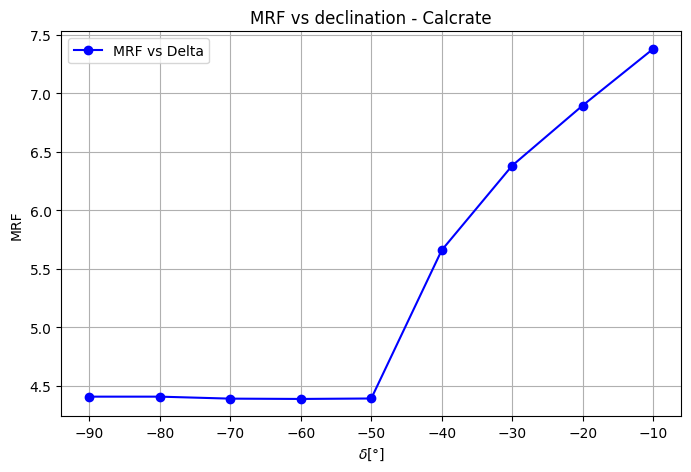

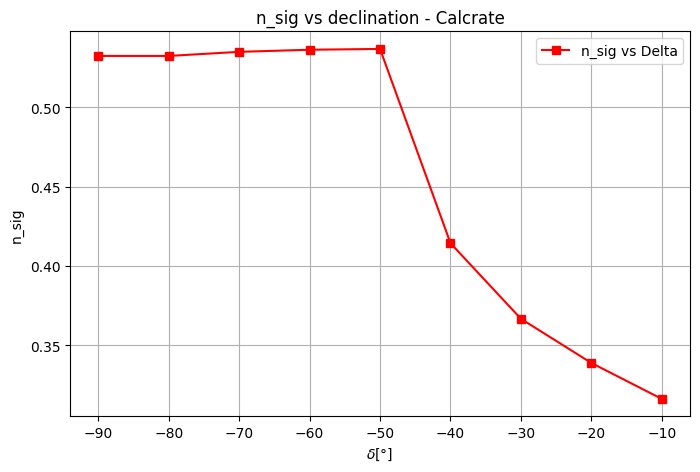

In [3]:

total_sig_anumu_c = [0.31614, 0.338821, 0.366676, 0.41437, 0.536904, 0.536398, 0.535064, 0.532494, 0.532494]
MRF_anumu_c = [7.37783, 6.89455, 6.38082, 5.65836, 4.39103, 4.38719, 4.38978, 4.40676, 4.40676]
num_points = len(MRF_anumu_c)
delta_list = np.linspace(-10, -90, num_points)
# Plot di MRF vs declinazione
plt.figure(figsize=(8, 5))
plt.plot(delta_list, MRF_anumu_c, marker='o', linestyle='-', color='b', label='MRF vs Delta')
plt.xlabel(r'$\delta [°]$')
plt.ylabel('MRF')

plt.title('MRF vs declination - Calcrate')
plt.legend()
plt.grid()
plt.show()

# Plot di n_sig vs declinazione
plt.figure(figsize=(8, 5))
plt.plot(delta_list,total_sig_anumu_c, marker='s', linestyle='-', color='r', label='n_sig vs Delta')
plt.xlabel(r'$\delta [°]$')
plt.ylabel('n_sig')

plt.title('n_sig vs declination - Calcrate')
plt.legend()
plt.grid()
plt.show()

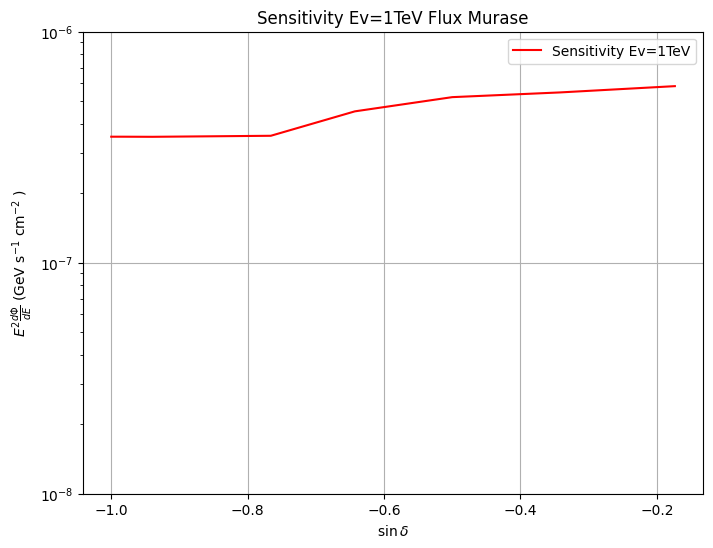

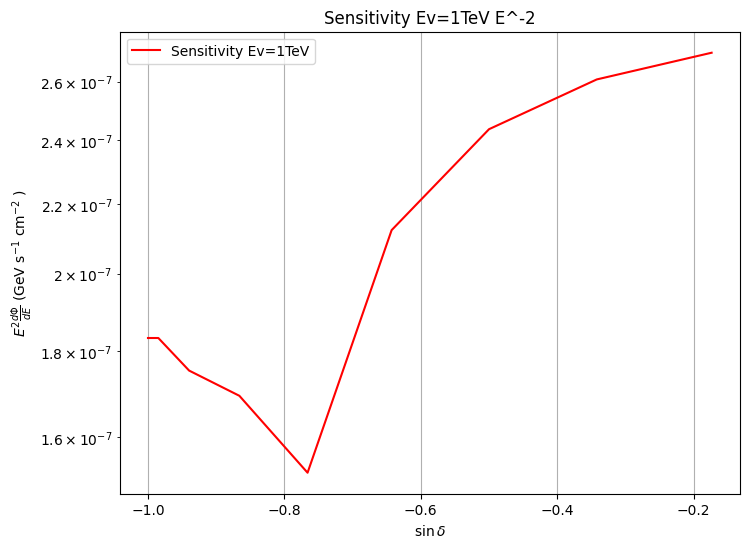

[array([5.81302741e-07]), array([5.46041192e-07]), array([5.20956475e-07]), array([4.52158523e-07]), array([3.54440321e-07]), array([3.52341762e-07]), array([3.50826135e-07]), array([3.51197861e-07]), array([3.51197861e-07])]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dati di input
#num_points = len(MRF_list)
#delta_list = np.linspace(-90, -10, num_points)
  # Converti in sin(δ) in radianti


d = 1*3.086e24
d_c = 1*3.086e22
# Caricamento dati
data = np.loadtxt("SN_IIn/SNIIn_20_block_25.dat", skiprows=1)
#data = np.loadtxt("flux_IIn.dat", skiprows=1)
#dN_dEv = data[15, 1]/1e9
#flux = dN_dEv/(4*np.pi*d**2)
MRF_tot = [3.44035, 3.23166, 3.0832, 2.67603, 2.0977, 2.08528, 2.07631, 2.07851, 2.07851]
MRF_2 = [1.60092, 1.54361, 1.44224, 1.25664, 0.902442, 1.00235, 1.03744, 1.0846, 1.0846]
#sensitivity = [flux * mrf for mrf in MRF_list]
if data[-1, -1] == 1:
    Ev_all = data[:, 0]
    Ev = Ev_all[Ev_all == 1.07461e12]  # Seleziona valori di Ev maggiori di 3e8
    Ev_c = Ev_all[Ev_all > 0.3e8]/1e9
    #Selezione del valore specifico di Ev
    S_IIn_start = 1e5 * pow(10., 0.1 * (25 - 1)) 
    S_IIn_stop = 1e5 * pow(10., 0.1 * (26 - 1))
    delta = S_IIn_stop - S_IIn_start
    dN_dEv = data[:, 7]
    dN_dEv_c = data[:, 7][Ev_all>0.3e8]
    dN_dEv = dN_dEv * delta
    dN_dEv = dN_dEv[Ev_all == 1.07461e12]
    
    flux = Ev**2*dN_dEv/(6*1e9*4*np.pi*d**2)
    flux_c = dN_dEv*1e9/(3*4*np.pi*d**2)
    


    

    # Esempio di utilizzo per Ev_c e dN_dEv_c
    save_data("flux_c1.txt", Ev_c, flux_c, header1="Ev_c [GeV]", header2="dN_dEv_c [s^-1 GeV^-1]")
# Calcola la sensibilità per ogni δ
    sensitivity = [flux_c * mrf for mrf in MRF_tot]
    sensitivity_c = [flux_c * mrf for mrf in MRF_2]



sin_delta = np.sin(np.radians(delta_list))
# Plot della sensibilità in funzione di sin(δ)
plt.figure(figsize=(8, 6))
plt.plot(sin_delta, sensitivity, color='red', label="Sensitivity Ev=1TeV")

# Formattazione del grafico
plt.xlabel(r"$\sin \delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
plt.yscale("log")  # Scala logaritmica
plt.ylim(1e-8,1e-6)
#plt.xscale("linear")  # x non serve in log
plt.grid(True)
#plt.title('Sensitivity Ev=1TeV without Calcrate')
plt.title('Sensitivity Ev=1TeV Flux Murase')
plt.legend()  # Aggiunge la legenda
plt.show()

# Plot della sensibilità in funzione di sin(δ)
plt.figure(figsize=(8, 6))
plt.plot(sin_delta, sensitivity_c, color='red', label="Sensitivity Ev=1TeV")

# Formattazione del grafico
plt.xlabel(r"$\sin \delta$")
plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
plt.yscale("log")  # Scala logaritmica
#plt.ylim(1e-3,1e-2)
#plt.xscale("linear")  # x non serve in log
plt.grid(True)
plt.title('Sensitivity Ev=1TeV E^-2')
plt.legend()  # Aggiunge la legenda
plt.show()
print(sensitivity)



0.03427031


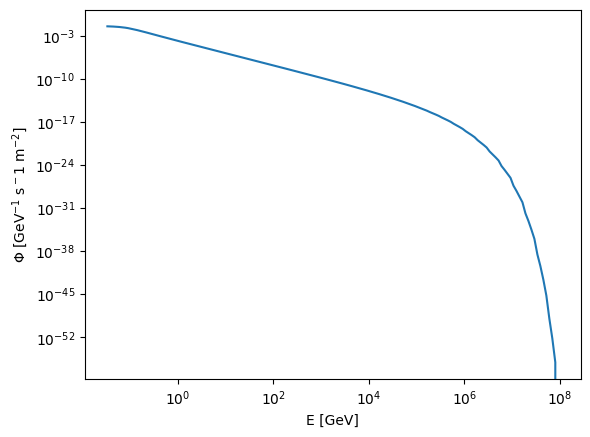

In [26]:
data = np.loadtxt('flux_c1.txt', skiprows=1)
e =  data[:,0]
f = data[:,1]
plt.plot(e,f)
plt.xlabel('E [GeV]')
#plt.xlim(1e-1,1e6)
print(data[1,1])
plt.ylabel(r'$\Phi$ [GeV$^{-1}$ s$^-1$ m$^{-2}$]')
plt.xscale('log')
plt.yscale('log')

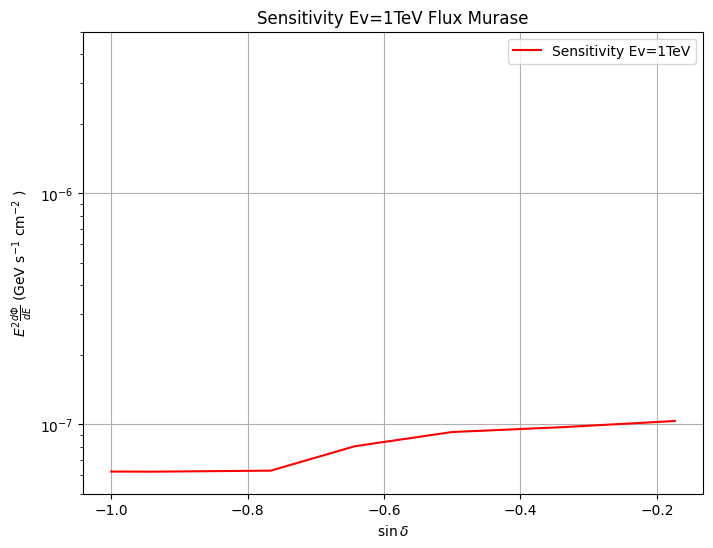

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Distanze
d = 1 * 3.086e24  # cm
d_m = 1 * 3.086e22  # m per calcrate


# Caricamento dati
data = np.loadtxt("SN_IIn/SNIIn_20_block_25.dat", skiprows=1)

# Definizione MRF
MRF_tot = np.array([3.44035, 3.23166, 3.0832, 2.67603, 2.0977, 2.08528, 2.07631, 2.07851, 2.07851])
MRF_2 = np.array([1.60092, 1.54361, 1.44224, 1.25664, 0.902442, 1.00235, 1.03744, 1.0846, 1.0846])

# Energia fissata a 1 TeV = 10^12 eV
E_fixed = 1.07461e12 # eV

# Controllo se ci sono abbastanza dati
if data.shape[1] > 7:
    Ev_all = data[:, 0]  # Energia in eV
    dN_dEv = data[:, 7]  # Spettro

    # Selezione dei valori vicini a 1 TeV
    Ev_mask = np.isclose(Ev_all, E_fixed)
    Ev = Ev_all[Ev_all==E_fixed]
    dN_dEv = dN_dEv[Ev_all==E_fixed]

    # Se il valore di Ev è vuoto, segnala errore
    if Ev.size == 0:
        print("Errore: Nessun valore di Ev corrisponde a 1 TeV!")
    else:
        # Calcolo intervallo delta tra i blocchi
        S_IIn_start = 1e5 * 10**(0.1 * (9 - 1))
        S_IIn_stop = 1e5 * 10**(0.1 * (26 - 1))
        delta = S_IIn_stop - S_IIn_start

        # Calcolo del flusso
        #dN_dEv *= delta
        flux = dN_dEv * 1e9 / (6 * 4 * np.pi * d**2)
        flux_c = Ev**2 * dN_dEv / (1e9 * 3 * 4 * np.pi * d**2)
        
        # Sensibilità
        sensitivity = flux_c * MRF_tot
        #save_data("flux_c2.txt", Ev, flux, header1="Ev [GeV]", header2="dN_dEv [s^-1 GeV^-1]")


        # Definizione degli angoli δ
        delta_list = np.linspace(-10, -90, len(MRF_tot))
        sin_delta = np.sin(np.radians(delta_list))

        # Plot 1: Sensibilità (Flux Murase)
        plt.figure(figsize=(8, 6))
        plt.plot(sin_delta, sensitivity, color='red', label="Sensitivity Ev=1TeV")
        plt.xlabel(r"$\sin \delta$")
        plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
        plt.yscale("log")
        plt.ylim(5e-8,5e-6)
        plt.grid(True)
        plt.title('Sensitivity Ev=1TeV Flux Murase')
        plt.legend()
        plt.show()


    
print()


In [17]:
print(dN_dEv)

[9.32713e+27]


SN2021uha


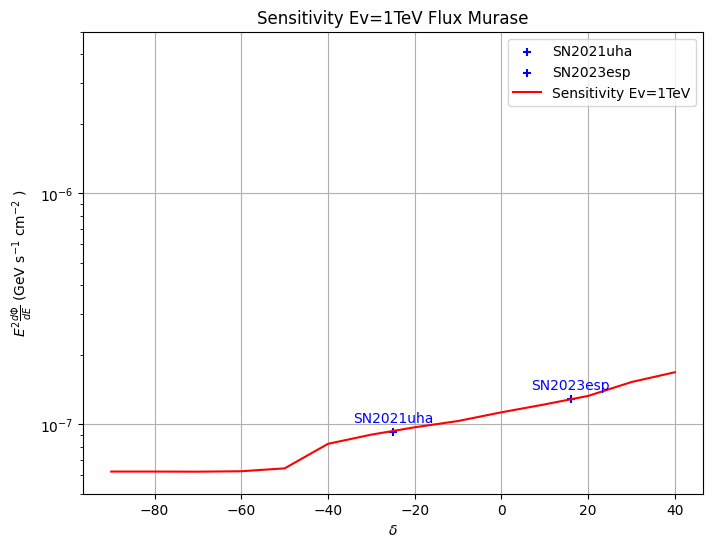

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Distanze
#SN2021uha
d = 1 * 1.043e26  # cm
d_m = 1 * 1.043e24  # m per calcrate
#SN2023esp
d_esp = 1.0306e26
d_esp_m = 1.0306e24 

# Caricamento dati
data = np.loadtxt("SN_IIn/SNIIn_20_block_25.dat", skiprows=1)

# Definizione MRF
MRF_1 = np.array([6390.13,5795.95,5047.4,4638.52,4286.11,3929.89, 3691.5, 3431.24, 3056.81, 2396.19, 2382, 2371.75, 2374.27, 2374.27])
MRF_3 =np.array([6239.09, 5658.95, 4928.1, 4528.8, 4184.8, 3837, 3604.24, 3350.14, 3056.81, 2393.5, 2325.7, 2315.69, 2318.15, 2318.15])


# Energia fissata a 1 TeV = 10^12 eV
E_fixed = 1.07461e12 # eV

# Controllo se ci sono abbastanza dati
if data.shape[1] > 7:
    Ev_all = data[:, 0]  # Energia in eV
    dN_dEv = data[:, 7]  # Spettro
    Ev_c = Ev_all[Ev_all > 0.3e8]/1e9
    # Selezione dei valori vicini a 1 TeV
    Ev_mask = np.isclose(Ev_all, E_fixed)
    Ev = Ev_all[Ev_mask]
    dN_dEv = dN_dEv[Ev_mask]
    dN_dEv_c = data[:, 7][Ev_all>0.3e8]
   
    # Calcolo intervallo delta tra i blocchi
    S_IIn_start = 1e5 * 10**(0.1 * (9 - 1))
    S_IIn_stop = 1e5 * 10**(0.1 * (26 - 1))
    delta = S_IIn_stop - S_IIn_start

    # Calcolo del flusso
    #dN_dEv *= delta
    #SN2021uha
    flux_c = dN_dEv_c * 1e9 / (6 * 4 * np.pi * d_m**2)
    flux = Ev**2 * dN_dEv / (1e9 * 3 * 4 * np.pi * d**2)
    #SN2023esp
    flux_c3 = dN_dEv_c * 1e9 / (6 * 4 * np.pi * d_esp_m**2)
    flux3 = Ev**2 * dN_dEv / (1e9 * 3 * 4 * np.pi * d_esp**2)
    # Sensibilità
    #SN2021uha
    sensitivity = flux * MRF_1
    
    sensitivity_esp = flux3*MRF_3
    save_data("flux_c3_esp.txt", Ev_c, flux_c3, header1="Ev [GeV]", header2="dN_dEv [s^-1 GeV^-1]")


    # Definizione degli angoli δ
    delta_list = np.linspace(40, -90, len(MRF_1))
    sin_delta = np.sin(np.radians(delta_list))
    #highlight_x = np.sin(np.radians(-25))
    #SN SOURCES
    uha_x = -25  #dec
    uha_y = flux * 3529.99 #sensitivity 
    
    esp_x = 16
    esp_y = flux3 * 4780.31
    # Plot 1: Sensibilità (Flux Murase)
    
    plt.figure(figsize=(8, 6))
    plt.yscale("log")
    plt.scatter(uha_x, uha_y, color='blue', zorder=1, label=f"SN2021uha", marker='+')
    plt.text(uha_x, uha_y*1.1, 'SN2021uha', fontsize=10, color='blue', ha='center')
    plt.scatter(esp_x, esp_y, color='blue', zorder=1, label=f"SN2023esp", marker='+')
    plt.text(esp_x, esp_y*1.1, 'SN2023esp', fontsize=10, color='blue', ha='center')
    plt.plot(delta_list, sensitivity_esp, color='red', label="Sensitivity Ev=1TeV")
    plt.xlabel(r"$\delta$")
    plt.ylabel(r"$E^2 \frac{d\Phi}{dE}$ (GeV s$^{-1}$ cm$^{-2}$ )")
    
    plt.ylim(5e-8,5e-6)
    plt.grid(True)
    plt.title('Sensitivity Ev=1TeV Flux Murase')
    plt.legend()
    plt.show()

        
print()


In [9]:
print((1e9 * 3 * 4 * np.pi * d**2))
print(dN_dEv )

4.1010941119380036e+62
[9.32713e+27]


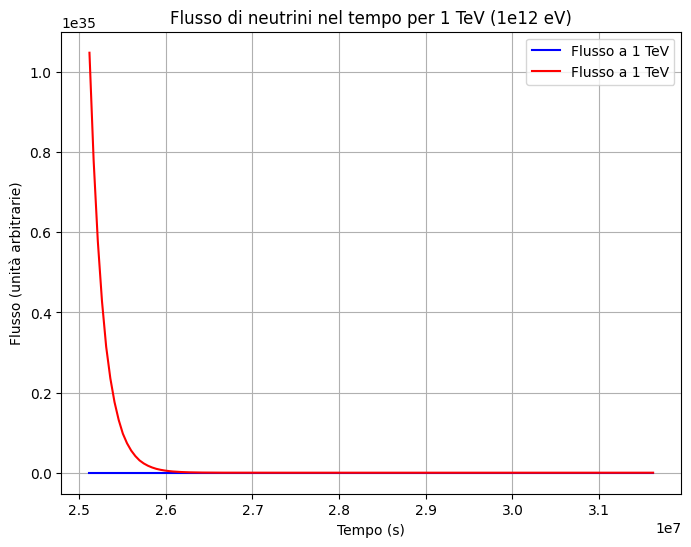

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Distanza in cm (ad esempio, 1 Mpc = 3.086e22 cm)
d = 1 * 3.086e22  

# Caricamento dei dati dal blocco 25 per il modello IIn
data = np.loadtxt("SN_IIn/SNIIn_20_block_25.dat", skiprows=1)

# Verifica che il flag per CR acceleration (colonna 14) sia abilitato
if data[-1, -1] == 1:
    # Colonna 1: Energia [eV]
    Ev_all = data[:, 0]
    
    # Filtra i dati: considera solo quelli con E > 3e8 eV (cioè > 0.3 GeV)
    mask = Ev_all > 3e8
    if np.sum(mask) == 0:
        raise ValueError("Nessun dato con E > 3e8 eV nel dataset.")
    
    # Applica il filtro ai dati
    Ev_filtered = Ev_all[mask]
    neutrino_flux = data[:, 7]  # Colonna 8: dN_neutrino/dE [eV^-1 s^-1]
    neutrino_flux_filtered = neutrino_flux[mask]
    
    # Calcolo del tempo per il blocco 25
    k = 25 - 1
    T_center_25 = 1e5 * 10**(0.1 * k)  # tempo centrale del blocco 25
    
    # Calcolo del tempo per il blocco successivo (26)
    k_next = 26 - 1
    T_center_26 = 1e5 * 10**(0.1 * k_next)  # tempo centrale del blocco 26
    
    # Calcolo di delta t tra blocco 25 e 26
    dt = T_center_26 - T_center_25
    
    # Creazione dei punti temporali per interpolazione
    time_range = np.linspace(T_center_25, T_center_26, 136)  # 100 punti di interpolazione tra i blocchi
    
    # Energia target a 1 TeV = 1e12 eV
    target_energy = 1.07461e12
    
    # Verifica se l'energia target è presente nei dati filtrati
    if target_energy not in Ev_filtered:
        raise ValueError(f"L'energia {target_energy} eV non è presente nei dati filtrati.")
    
    # Trova l'indice corrispondente all'energia 1 TeV (1e12 eV)
    index_1TeV = np.where(Ev_filtered == target_energy)[0][0]
    
    # Interpolazione del flusso per l'energia 1 TeV
    flux_points = np.array([neutrino_flux_filtered[index_1TeV], neutrino_flux_filtered[index_1TeV]])  # Flusso costante per 1 TeV
    time_points = np.array([T_center_25, T_center_26])  # Tempi dei blocchi
    
    # Creiamo l'interpolatore per il flusso a 1 TeV
    flux_interpolator = interp1d(time_points, flux_points, kind='linear', fill_value='extrapolate')
    
    # Calcoliamo il flusso interpolato per ogni punto temporale
    flux_interpolated_1TeV = flux_interpolator(time_range)
    
    # Plot del flusso interpolato per l'energia 1 TeV
    plt.figure(figsize=(8, 6))
    plt.plot(time_range, flux_interpolated_1TeV, label=f'Flusso a 1 TeV', color='b')
    plt.plot(time_range, neutrino_flux_filtered, label=f'Flusso a 1 TeV', color='r')
    plt.xlabel("Tempo (s)")
    plt.ylabel("Flusso (unità arbitrarie)")
    plt.title(f"Flusso di neutrini nel tempo per 1 TeV (1e12 eV)")
    plt.grid(True)
    plt.legend()
    plt.show()

else:
    print("Il flag per CR acceleration non è abilitato nel dataset.")


In [1]:
# Calcolare 10^5.8 secondi e convertirli in giorni
seconds = (10**7.5-10**5.8)
days = seconds / (60 * 60 * 24)  # Conversione da secondi a giorni
print(days)


358.70161177318977
